# Aoranema — Personalized Movie Recommendation

Notebook eksperimen lengkap untuk fitur **Personalized Movie Recommendation** menggunakan **MovieLens 32M**.

### Tujuan
Membangun model yang mempelajari hubungan:

**user preference per genre + genre film → probabilitas user menyukai film**

Kemudian probabilitas tersebut dipakai sebagai **recommendation score**, diurutkan, dan diambil **Top-10**.

### Model yang dibandingkan
1. **Logistic Regression scalable** (`SGDClassifier(loss="log_loss")`) sebagai baseline.
2. **XGBoost Classifier** sebagai kandidat model utama dan menggunakan GPU T4 bila tersedia.

### Dataset Kaggle
Private dataset:

`aoranema-movielens-32m`

Notebook akan mencari otomatis:
- `ratings.csv`
- `movies.csv`
- `links.csv` (opsional, belum dipakai untuk training v1)

### Sebelum Run All di Kaggle
1. Buka **Settings → Accelerator → GPU T4**.
2. Tambahkan private dataset **aoranema-movielens-32m** melalui **Add Input**.
3. Jalankan notebook dari atas ke bawah.

> GPU terutama mempercepat XGBoost. Loading CSV, EDA, dan feature engineering tetap banyak menggunakan CPU/RAM.

## Metodologi singkat

Kita sengaja **tidak** memasukkan `userId` atau `movieId` sebagai feature utama model.

MovieLens digunakan untuk membangun pola historis:

1. Rating lama user → **preference genre user**.
2. Genre film → **movie features** 0/1.
3. Rating film yang sedang diprediksi → target:
   - rating `>= 4.0` → `LIKE = 1`
   - rating `<= 3.0` → `DISLIKE = 0`
   - rating `3.5` → dikeluarkan dari target v1.

Untuk mengurangi leakage, notebook memakai **global chronological split**:

- 0–50% waktu: membangun preference awal untuk training.
- 50–70%: data training model.
- 70–85%: validation.
- 85–100%: test.

Preference validation dibangun hanya dari histori sampai batas train, dan preference test dibangun hanya dari histori sampai batas validation.

Jika suatu genre belum mempunyai histori untuk user, model **tidak diberi angka 0**. Notebook menggunakan **smoothed global prior** sebagai nilai numerik fallback. Secara aplikasi, statusnya tetap dapat disimpan sebagai `UNKNOWN`.

In [1]:
# ============================================================
# 0. SETUP & CONFIGURATION
# ============================================================

from pathlib import Path
import os
import gc
import json
import math
import re
import shutil
import subprocess
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)
import joblib

import xgboost as xgb
from packaging import version

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# "full" = MovieLens 32M penuh
# "debug" = sebagian ratings untuk memastikan pipeline benar
RUN_MODE = "full"
DEBUG_N_ROWS = 1_000_000

RATING_MIN = 0.5
RATING_MAX = 5.0
NEUTRAL_RATING = 3.5
LIKE_THRESHOLD = 4.0

# Smoothing untuk preference genre.
PREFERENCE_ALPHA = 5.0

# Global chronological split.
PROFILE_Q = 0.50
TRAIN_Q = 0.70
VAL_Q = 0.85

# XGBoost.
XGB_N_ESTIMATORS = 1500
XGB_LEARNING_RATE = 0.05
XGB_MAX_DEPTH = 6
XGB_MAX_BIN = 128
XGB_EARLY_STOPPING = 75

# Ranking evaluation.
RANKING_K = 10
MAX_RANKING_USERS = 50_000

# Threshold search.
THRESHOLD_SEARCH_MAX_ROWS = 1_000_000

ARTIFACT_DIR = Path("/kaggle/working/aoranema_recommender_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)
print("XGBoost:", xgb.__version__)
print("Mode   :", RUN_MODE)

Pandas : 2.3.3
NumPy  : 2.0.2
XGBoost: 3.2.0
Mode   : full


In [2]:
# ============================================================
# 1. CHECK GPU
# ============================================================

def has_nvidia_gpu():
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=False,
        )
        print(result.stdout[:2500])
        return result.returncode == 0 and "NVIDIA" in result.stdout
    except Exception:
        return False

GPU_AVAILABLE = has_nvidia_gpu()
print("GPU detected:", GPU_AVAILABLE)

if not GPU_AVAILABLE:
    print(
        "\nWARNING: GPU tidak terdeteksi. "
        "XGBoost tetap bisa jalan di CPU, tetapi training full 32M akan lebih lama."
    )

Fri Sep 18 06:35:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================
# 2. LOCATE KAGGLE DATASET - ROBUST AUTO DETECTION
# ============================================================

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

assert KAGGLE_INPUT.exists(), (
    "/kaggle/input tidak ditemukan. "
    "Pastikan notebook dijalankan di Kaggle."
)

# Cari semua ratings.csv di seluruh Kaggle Input
ratings_candidates = list(KAGGLE_INPUT.rglob("ratings.csv"))

print("ratings.csv ditemukan:")
for p in ratings_candidates:
    print(" -", p)

# Pilih folder yang mempunyai ratings.csv DAN movies.csv
DATA_DIR = None

for ratings_path in ratings_candidates:
    candidate_dir = ratings_path.parent

    if (candidate_dir / "movies.csv").exists():
        DATA_DIR = candidate_dir
        break

assert DATA_DIR is not None, (
    "Folder MovieLens tidak ditemukan. "
    "Pastikan ratings.csv dan movies.csv tersedia di Kaggle Input."
)

RATINGS_PATH = DATA_DIR / "ratings.csv"
MOVIES_PATH = DATA_DIR / "movies.csv"

LINKS_PATH = DATA_DIR / "links.csv"
if not LINKS_PATH.exists():
    LINKS_PATH = None

TAGS_PATH = DATA_DIR / "tags.csv"
if not TAGS_PATH.exists():
    TAGS_PATH = None

print("\nMovieLens directory :", DATA_DIR)
print("ratings.csv        :", RATINGS_PATH)
print("movies.csv         :", MOVIES_PATH)
print("links.csv          :", LINKS_PATH)
print("tags.csv           :", TAGS_PATH)

ratings.csv ditemukan:
 - /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/ratings.csv

MovieLens directory : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m
ratings.csv        : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/ratings.csv
movies.csv         : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/movies.csv
links.csv          : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/links.csv
tags.csv           : /kaggle/input/datasets/onallaaldeanuva/aoranema-movielens-32m/ml-32m/tags.csv


In [4]:
# ============================================================
# 3. LOAD MOVIELENS 32M
# ============================================================

rating_dtypes = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

movie_dtypes = {
    "movieId": "int32",
    "title": "string",
    "genres": "string",
}

nrows = DEBUG_N_ROWS if RUN_MODE == "debug" else None

t0 = time.time()

ratings = pd.read_csv(
    RATINGS_PATH,
    dtype=rating_dtypes,
    nrows=nrows,
)

movies = pd.read_csv(
    MOVIES_PATH,
    dtype=movie_dtypes,
)

links = None
if LINKS_PATH is not None:
    links = pd.read_csv(LINKS_PATH)

print(f"Loaded in {time.time() - t0:.1f} sec")
print("ratings shape:", ratings.shape)
print("movies shape :", movies.shape)
print("links shape  :", None if links is None else links.shape)

display(ratings.head())
display(movies.head())

Loaded in 14.0 sec
ratings shape: (32000204, 4)
movies shape : (87585, 3)
links shape  : (87585, 3)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 4. EDA

Tujuan EDA:
- memastikan skala data benar,
- melihat rentang rating,
- mengecek missing value,
- melihat jumlah user/film,
- memeriksa distribusi genre.

In [5]:
# ============================================================
# 4.1 BASIC DATA QUALITY
# ============================================================

print("Ratings null:")
display(ratings.isna().sum())

print("\nMovies null:")
display(movies.isna().sum())

print("\nUnique users :", ratings["userId"].nunique())
print("Unique movies in ratings:", ratings["movieId"].nunique())
print("Movies in metadata      :", movies["movieId"].nunique())

print("\nRating min/max:", ratings["rating"].min(), ratings["rating"].max())

date_min = pd.to_datetime(ratings["timestamp"].min(), unit="s", utc=True)
date_max = pd.to_datetime(ratings["timestamp"].max(), unit="s", utc=True)
print("Rating period:", date_min, "→", date_max)

print("\nRating distribution:")
rating_dist = ratings["rating"].value_counts().sort_index()
display(rating_dist.to_frame("count"))

Ratings null:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Movies null:


movieId    0
title      0
genres     0
dtype: int64


Unique users : 200948
Unique movies in ratings: 84432
Movies in metadata      : 87585

Rating min/max: 0.5 5.0
Rating period: 1995-01-09 11:46:44+00:00 → 2023-10-13 02:29:07+00:00

Rating distribution:


,count
rating,
0.5,525132
1.0,946675
1.5,531063
2.0,2028622
2.5,1685386
3.0,6054990
3.5,4290105
4.0,8367654
4.5,2974000


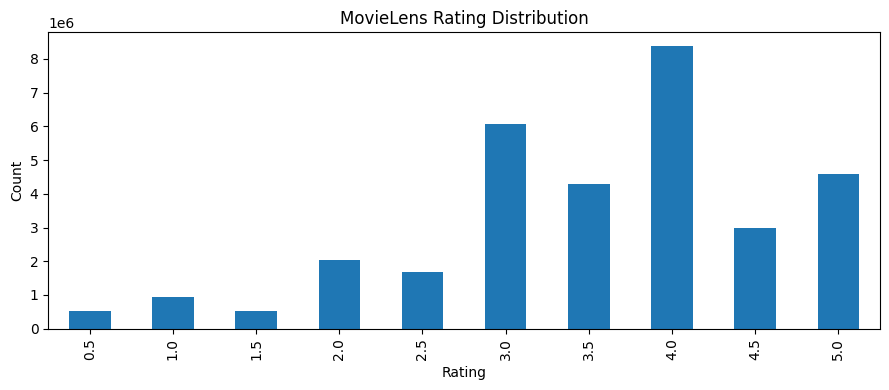

In [6]:
# ============================================================
# 4.2 RATING DISTRIBUTION PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))
rating_dist.plot(kind="bar", ax=ax)
ax.set_title("MovieLens Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Number of genres: 19


,movie_count
Drama,34175
Comedy,23124
Thriller,11823
Romance,10369
Action,9668
Documentary,9363
Horror,8654
Crime,6976
Adventure,5402
Sci-Fi,4907


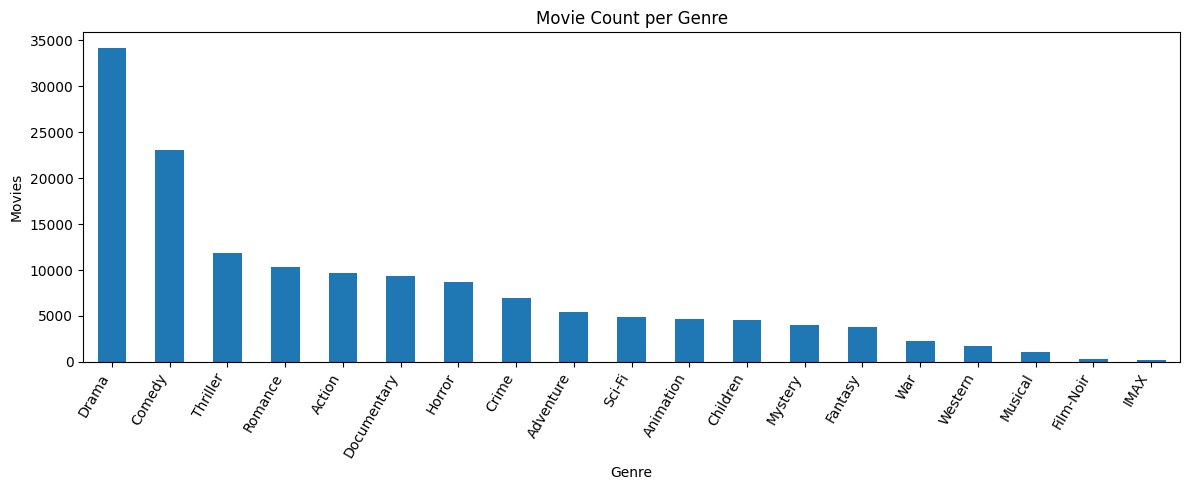

15

In [7]:
# ============================================================
# 4.3 GENRE EDA
# ============================================================

genre_dummy_eda = movies["genres"].fillna("").str.get_dummies(sep="|")

if "(no genres listed)" in genre_dummy_eda.columns:
    genre_dummy_eda = genre_dummy_eda.drop(columns=["(no genres listed)"])

genre_counts = genre_dummy_eda.sum().sort_values(ascending=False)

print("Number of genres:", len(genre_counts))
display(genre_counts.to_frame("movie_count"))

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind="bar", ax=ax)
ax.set_title("Movie Count per Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Movies")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

del genre_dummy_eda
gc.collect()

## 5. Genre Encoding

Setiap film direpresentasikan dengan **multi-hot encoding**.

Contoh `Action | Sci-Fi`:

- `movie_action = 1`
- `movie_sci_fi = 1`
- genre lain = `0`

In [8]:
# ============================================================
# 5. BUILD MOVIE GENRE MATRIX
# ============================================================

genre_df = movies["genres"].fillna("").str.get_dummies(sep="|")

if "(no genres listed)" in genre_df.columns:
    genre_df = genre_df.drop(columns=["(no genres listed)"])

GENRES = sorted(genre_df.columns.tolist())
genre_df = genre_df[GENRES].astype("uint8")

movie_genre_matrix = genre_df.to_numpy(dtype=np.uint8)
genre_sparse = csr_matrix(movie_genre_matrix.astype(np.float32))

movie_index = pd.Index(movies["movieId"].to_numpy())
user_ids = np.sort(ratings["userId"].unique())
user_index = pd.Index(user_ids)

movie_pos = movie_index.get_indexer(ratings["movieId"]).astype(np.int32)
user_pos = user_index.get_indexer(ratings["userId"]).astype(np.int32)

assert (movie_pos >= 0).all(), "Ada movieId ratings yang tidak ditemukan di movies.csv"
assert (user_pos >= 0).all(), "Mapping user gagal."

N_USERS = len(user_ids)
N_MOVIES = len(movies)
N_GENRES = len(GENRES)

print("Genres:", GENRES)
print("N_USERS :", N_USERS)
print("N_MOVIES:", N_MOVIES)
print("N_GENRES:", N_GENRES)

Genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
N_USERS : 200948
N_MOVIES: 87585
N_GENRES: 19


## 6. Time Split

Kita memakai urutan waktu agar preference berasal dari **masa lalu**, bukan dari data masa depan.

- histori awal → preference untuk train,
- histori sampai train → preference untuk validation,
- histori sampai validation → preference untuk test.

In [9]:
# ============================================================
# 6. GLOBAL CHRONOLOGICAL SPLIT
# ============================================================

timestamps = ratings["timestamp"].to_numpy(dtype=np.int64)
rating_values = ratings["rating"].to_numpy(dtype=np.float32)

q_profile, q_train, q_val = ratings["timestamp"].quantile(
    [PROFILE_Q, TRAIN_Q, VAL_Q]
).astype("int64").tolist()

PROFILE_END = int(q_profile)
TRAIN_END = int(q_train)
VAL_END = int(q_val)

print("PROFILE_END:", pd.to_datetime(PROFILE_END, unit="s", utc=True))
print("TRAIN_END  :", pd.to_datetime(TRAIN_END, unit="s", utc=True))
print("VAL_END    :", pd.to_datetime(VAL_END, unit="s", utc=True))

profile_history_mask = timestamps <= PROFILE_END

train_target_mask = (
    (timestamps > PROFILE_END)
    & (timestamps <= TRAIN_END)
    & (rating_values != NEUTRAL_RATING)
)

val_target_mask = (
    (timestamps > TRAIN_END)
    & (timestamps <= VAL_END)
    & (rating_values != NEUTRAL_RATING)
)

test_target_mask = (
    (timestamps > VAL_END)
    & (rating_values != NEUTRAL_RATING)
)

print("\nRows used:")
print("Profile history :", int(profile_history_mask.sum()))
print("Train targets   :", int(train_target_mask.sum()))
print("Validation      :", int(val_target_mask.sum()))
print("Test            :", int(test_target_mask.sum()))

PROFILE_END: 2010-04-30 10:03:32+00:00
TRAIN_END  : 2016-10-13 13:27:36+00:00
VAL_END    : 2019-11-09 20:15:07+00:00

Rows used:
Profile history : 16000102
Train targets   : 5287455
Validation      : 3979811
Test            : 3947390


## 7. User Preference Profile

Preference genre dihitung dari **rating historis user**.

Langkah:
1. total rating user pada tiap genre,
2. jumlah interaksi user pada tiap genre,
3. smoothing ke global mean genre,
4. normalisasi dari skala rating `0.5–5.0` ke `0–1`.

Jika user belum punya histori genre tertentu, fallback numeriknya adalah **global prior**, bukan `0`.

In [10]:
# ============================================================
# 7. BUILD USER GENRE PREFERENCES
# ============================================================

def normalize_rating_to_01(x):
    x = np.asarray(x, dtype=np.float32)
    out = (x - RATING_MIN) / (RATING_MAX - RATING_MIN)
    return np.clip(out, 0.0, 1.0)

def build_user_genre_profile(history_mask, label):
    '''
    Menghasilkan preference matrix [n_users, n_genres] dari histori
    yang tersedia sebelum periode target.
    '''
    idx = np.flatnonzero(history_mask)
    u = user_pos[idx]
    m = movie_pos[idx]
    r = rating_values[idx]

    print(f"\nBuilding {label} profile from {len(idx):,} historical interactions...")

    R = csr_matrix(
        (r, (u, m)),
        shape=(N_USERS, N_MOVIES),
        dtype=np.float32,
    )
    B = csr_matrix(
        (np.ones(len(idx), dtype=np.float32), (u, m)),
        shape=(N_USERS, N_MOVIES),
        dtype=np.float32,
    )

    rating_sum = (R @ genre_sparse).toarray().astype(np.float32)
    rating_count = (B @ genre_sparse).toarray().astype(np.float32)

    overall_mean = float(r.mean())
    total_sum_per_genre = rating_sum.sum(axis=0)
    total_count_per_genre = rating_count.sum(axis=0)

    global_mean = np.divide(
        total_sum_per_genre,
        total_count_per_genre,
        out=np.full(N_GENRES, overall_mean, dtype=np.float32),
        where=total_count_per_genre > 0,
    ).astype(np.float32)

    smoothed_mean = (
        rating_sum + PREFERENCE_ALPHA * global_mean[None, :]
    ) / (
        rating_count + PREFERENCE_ALPHA
    )

    preference = normalize_rating_to_01(smoothed_mean).astype(np.float32)
    global_prior = normalize_rating_to_01(global_mean).astype(np.float32)

    known_ratio = (rating_count > 0).mean(axis=0)

    del R, B, rating_sum
    gc.collect()

    return {
        "preference": preference,
        "count": rating_count,
        "global_mean_rating": global_mean,
        "global_prior": global_prior,
        "known_ratio": known_ratio,
    }

train_profile_pack = build_user_genre_profile(
    timestamps <= PROFILE_END,
    "TRAIN",
)

val_profile_pack = build_user_genre_profile(
    timestamps <= TRAIN_END,
    "VALIDATION",
)

test_profile_pack = build_user_genre_profile(
    timestamps <= VAL_END,
    "TEST",
)

print("\nGlobal genre prior (train history):")
display(
    pd.DataFrame({
        "genre": GENRES,
        "global_prior_0_1": train_profile_pack["global_prior"],
        "known_user_ratio": train_profile_pack["known_ratio"],
    }).sort_values("global_prior_0_1", ascending=False)
)


Building TRAIN profile from 16,000,102 historical interactions...

Building VALIDATION profile from 22,400,143 historical interactions...

Building TEST profile from 27,200,173 historical interactions...

Global genre prior (train history):


,genre,global_prior_0_1,known_user_ratio
9,Film-Noir,0.775816,0.234384
17,War,0.736726,0.502215
6,Documentary,0.724640,0.207158
7,Drama,0.703525,0.559234
5,Crime,0.701437,0.553178
13,Mystery,0.699409,0.516527
11,IMAX,0.698882,0.348513
2,Animation,0.690778,0.479059
12,Musical,0.680368,0.469096
18,Western,0.679048,0.401706


## 8. Feature Engineering untuk Model

Untuk setiap pasangan user–film:

### User preference
`user_pref_action`, `user_pref_sci_fi`, dst.

### Movie genre
`movie_action`, `movie_sci_fi`, dst.

### Match
`user_pref_genre × movie_genre`

Match feature membuat baseline linear tetap dapat menangkap kecocokan genre secara personal.

In [11]:
# ============================================================
# 8. BUILD MODEL MATRICES
# ============================================================

def slugify_genre(g):
    return re.sub(r"[^a-z0-9]+", "_", g.lower()).strip("_")

GENRE_SLUGS = [slugify_genre(g) for g in GENRES]

FEATURE_NAMES = (
    [f"user_pref_{g}" for g in GENRE_SLUGS]
    + [f"movie_{g}" for g in GENRE_SLUGS]
    + [f"match_{g}" for g in GENRE_SLUGS]
)

def build_model_matrix(target_mask, profile_matrix, label, batch_size=500_000):
    idx = np.flatnonzero(target_mask)
    n = len(idx)
    g = N_GENRES

    X = np.empty((n, g * 3), dtype=np.float32)
    y = (rating_values[idx] >= LIKE_THRESHOLD).astype(np.uint8)
    users_for_ranking = user_pos[idx].astype(np.int32)

    print(f"Building {label}: {n:,} rows × {g*3} features")

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = idx[start:end]

        pref = profile_matrix[user_pos[batch_idx]]
        mg = movie_genre_matrix[movie_pos[batch_idx]].astype(np.float32)

        X[start:end, :g] = pref
        X[start:end, g:2*g] = mg
        X[start:end, 2*g:3*g] = pref * mg

        if start == 0 or end == n or start % (batch_size * 5) == 0:
            print(f"  {end:,}/{n:,}")

    print(
        f"{label} class balance: "
        f"LIKE={int(y.sum()):,} ({y.mean():.3f}), "
        f"DISLIKE={int((1-y).sum()):,}"
    )

    return X, y, users_for_ranking, idx

X_train, y_train, users_train, idx_train = build_model_matrix(
    train_target_mask,
    train_profile_pack["preference"],
    "TRAIN",
)

X_val, y_val, users_val, idx_val = build_model_matrix(
    val_target_mask,
    val_profile_pack["preference"],
    "VALIDATION",
)

X_test, y_test, users_test, idx_test = build_model_matrix(
    test_target_mask,
    test_profile_pack["preference"],
    "TEST",
)

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Building TRAIN: 5,287,455 rows × 57 features
  500,000/5,287,455
  3,000,000/5,287,455
  5,287,455/5,287,455
TRAIN class balance: LIKE=3,193,869 (0.604), DISLIKE=2,093,586
Building VALIDATION: 3,979,811 rows × 57 features
  500,000/3,979,811
  3,000,000/3,979,811
  3,979,811/3,979,811
VALIDATION class balance: LIKE=2,378,263 (0.598), DISLIKE=1,601,548
Building TEST: 3,947,390 rows × 57 features
  500,000/3,947,390
  3,000,000/3,947,390
  3,947,390/3,947,390
TEST class balance: LIKE=2,374,094 (0.601), DISLIKE=1,573,296

Shapes:
X_train: (5287455, 57) y_train: (5287455,)
X_val  : (3979811, 57) y_val  : (3979811,)
X_test : (3947390, 57) y_test : (3947390,)


## 9. Evaluasi

### Classification
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC
- Confusion Matrix

### Ranking
- Precision@10
- Recall@10
- NDCG@10

Ranking metric v1 dihitung dari held-out observed interactions user.

In [12]:
# ============================================================
# 9. EVALUATION HELPERS
# ============================================================

def find_best_f1_threshold(y_true, y_score, max_rows=THRESHOLD_SEARCH_MAX_ROWS):
    if len(y_true) > max_rows:
        rng = np.random.default_rng(RANDOM_STATE)
        take = rng.choice(len(y_true), size=max_rows, replace=False)
        yt = y_true[take]
        ys = y_score[take]
    else:
        yt = y_true
        ys = y_score

    precision, recall, thresholds = precision_recall_curve(yt, ys)
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    best_idx = int(np.nanargmax(f1[:-1]))
    return float(thresholds[best_idx]), float(f1[best_idx])

def classification_metrics(y_true, y_score, threshold):
    pred = (y_score >= threshold).astype(np.uint8)
    cm = confusion_matrix(y_true, pred)

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "confusion_matrix": cm.tolist(),
    }

def ranking_metrics_at_k(
    users,
    y_true,
    y_score,
    k=10,
    max_users=MAX_RANKING_USERS,
):
    df = pd.DataFrame({
        "user": users,
        "y": y_true.astype(np.uint8),
        "score": y_score.astype(np.float32),
    })

    stats = df.groupby("user")["y"].agg(["size", "sum"])
    eligible = stats[(stats["size"] >= 2) & (stats["sum"] >= 1)].index.to_numpy()

    if len(eligible) == 0:
        return {
            f"precision@{k}": np.nan,
            f"recall@{k}": np.nan,
            f"ndcg@{k}": np.nan,
            "ranking_users": 0,
        }

    if len(eligible) > max_users:
        rng = np.random.default_rng(RANDOM_STATE)
        eligible = rng.choice(eligible, size=max_users, replace=False)

    eligible_set = set(eligible.tolist())
    rdf = df[df["user"].isin(eligible_set)].copy()

    rdf = rdf.sort_values(["user", "score"], ascending=[True, False])
    top = rdf.groupby("user", sort=False).head(k).copy()
    top["rank"] = top.groupby("user", sort=False).cumcount() + 1
    top["discounted_gain"] = top["y"] / np.log2(top["rank"] + 1)

    hits = top.groupby("user")["y"].sum()
    rec_count = top.groupby("user")["y"].size()
    total_pos = rdf.groupby("user")["y"].sum()

    precision = (hits / rec_count).mean()
    recall = (hits / total_pos).mean()

    dcg = top.groupby("user")["discounted_gain"].sum()

    discounts = np.array(
        [0.0] + [1.0 / np.log2(i + 1) for i in range(1, k + 1)],
        dtype=np.float64,
    )
    idcg_lookup = np.cumsum(discounts)

    ideal_hits = np.minimum(total_pos.astype(int), k)
    idcg = pd.Series(
        idcg_lookup[ideal_hits.to_numpy()],
        index=ideal_hits.index,
    )

    ndcg = (dcg / idcg).replace([np.inf, -np.inf], np.nan).dropna().mean()

    return {
        f"precision@{k}": float(precision),
        f"recall@{k}": float(recall),
        f"ndcg@{k}": float(ndcg),
        "ranking_users": int(len(eligible)),
    }

## 10. Logistic Regression Baseline

Untuk jutaan baris digunakan `SGDClassifier(loss="log_loss")`.

Ini tetap logistic classifier, tetapi jauh lebih scalable dibanding solver batch klasik.

In [13]:
# ============================================================
# 10. TRAIN LOGISTIC BASELINE
# ============================================================

t0 = time.time()

logreg = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    max_iter=40,
    tol=1e-3,
    random_state=RANDOM_STATE,
    average=True,
    early_stopping=True,
    validation_fraction=0.08,
    n_iter_no_change=5,
)

logreg.fit(X_train, y_train)

logreg_train_sec = time.time() - t0
print(f"Logistic baseline trained in {logreg_train_sec:.1f} sec")

log_val_score = logreg.predict_proba(X_val)[:, 1].astype(np.float32)
log_threshold, log_val_best_f1 = find_best_f1_threshold(y_val, log_val_score)

print("Best validation threshold:", log_threshold)
print("Validation F1 at threshold:", log_val_best_f1)

log_val_class = classification_metrics(y_val, log_val_score, log_threshold)
log_val_rank = ranking_metrics_at_k(
    users_val, y_val, log_val_score, k=RANKING_K
)

print("\nValidation classification:")
display(pd.DataFrame([log_val_class]).drop(columns=["confusion_matrix"]))

print("\nValidation ranking:")
display(pd.DataFrame([log_val_rank]))

Logistic baseline trained in 17.1 sec
Best validation threshold: 0.3458169996738434
Validation F1 at threshold: 0.7546245623989262

Validation classification:


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.345817,0.616377,0.61053,0.988851,0.754946,0.629553,0.69715



Validation ranking:


,precision@10,recall@10,ndcg@10,ranking_users
0,0.779985,0.255706,0.794259,30618


## 11. XGBoost

Jika T4 aktif, XGBoost menggunakan GPU. Ada fallback CPU jika CUDA gagal.

In [14]:
# ============================================================
# 11. TRAIN XGBOOST
# ============================================================

xgb_params = dict(
    n_estimators=XGB_N_ESTIMATORS,
    learning_rate=XGB_LEARNING_RATE,
    max_depth=XGB_MAX_DEPTH,
    max_bin=XGB_MAX_BIN,
    subsample=0.85,
    colsample_bytree=0.90,
    min_child_weight=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    tree_method="hist",
    early_stopping_rounds=XGB_EARLY_STOPPING,
)

if GPU_AVAILABLE:
    if version.parse(xgb.__version__) >= version.parse("2.0.0"):
        xgb_params["device"] = "cuda"
    else:
        xgb_params["tree_method"] = "gpu_hist"

xgb_model = xgb.XGBClassifier(**xgb_params)

t0 = time.time()

try:
    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )
except Exception as e:
    if GPU_AVAILABLE:
        print("\nGPU training failed. Falling back to CPU.")
        print("Reason:", repr(e))
        xgb_params.pop("device", None)
        xgb_params["tree_method"] = "hist"
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=100,
        )
    else:
        raise

xgb_train_sec = time.time() - t0
print(f"\nXGBoost trained in {xgb_train_sec:.1f} sec")

xgb_val_score = xgb_model.predict_proba(X_val)[:, 1].astype(np.float32)
xgb_threshold, xgb_val_best_f1 = find_best_f1_threshold(y_val, xgb_val_score)

print("Best validation threshold:", xgb_threshold)
print("Validation F1 at threshold:", xgb_val_best_f1)

xgb_val_class = classification_metrics(y_val, xgb_val_score, xgb_threshold)
xgb_val_rank = ranking_metrics_at_k(
    users_val, y_val, xgb_val_score, k=RANKING_K
)

print("\nValidation classification:")
display(pd.DataFrame([xgb_val_class]).drop(columns=["confusion_matrix"]))

print("\nValidation ranking:")
display(pd.DataFrame([xgb_val_rank]))

[0]	validation_0-aucpr:0.69743
[100]	validation_0-aucpr:0.71776
[200]	validation_0-aucpr:0.71859
[300]	validation_0-aucpr:0.71860
[337]	validation_0-aucpr:0.71849

XGBoost trained in 27.9 sec
Best validation threshold: 0.3825523853302002
Validation F1 at threshold: 0.7572921958833669

Validation classification:


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.382552,0.630733,0.623298,0.965707,0.757611,0.652767,0.718383



Validation ranking:


,precision@10,recall@10,ndcg@10,ranking_users
0,0.800134,0.259251,0.814813,30618


## 12. Model Selection

Karena tujuan akhir adalah ranking rekomendasi, model dipilih berdasarkan **Validation NDCG@10**.

In [15]:
# ============================================================
# 12. MODEL SELECTION
# ============================================================

comparison_val = pd.DataFrame([
    {
        "model": "logistic_sgd",
        "f1": log_val_class["f1"],
        "roc_auc": log_val_class["roc_auc"],
        "pr_auc": log_val_class["pr_auc"],
        f"precision@{RANKING_K}": log_val_rank[f"precision@{RANKING_K}"],
        f"recall@{RANKING_K}": log_val_rank[f"recall@{RANKING_K}"],
        f"ndcg@{RANKING_K}": log_val_rank[f"ndcg@{RANKING_K}"],
        "train_seconds": logreg_train_sec,
    },
    {
        "model": "xgboost",
        "f1": xgb_val_class["f1"],
        "roc_auc": xgb_val_class["roc_auc"],
        "pr_auc": xgb_val_class["pr_auc"],
        f"precision@{RANKING_K}": xgb_val_rank[f"precision@{RANKING_K}"],
        f"recall@{RANKING_K}": xgb_val_rank[f"recall@{RANKING_K}"],
        f"ndcg@{RANKING_K}": xgb_val_rank[f"ndcg@{RANKING_K}"],
        "train_seconds": xgb_train_sec,
    },
]).sort_values(f"ndcg@{RANKING_K}", ascending=False)

display(comparison_val)

SELECTED_MODEL_NAME = comparison_val.iloc[0]["model"]

if SELECTED_MODEL_NAME == "xgboost":
    selected_model = xgb_model
    selected_threshold = xgb_threshold
else:
    selected_model = logreg
    selected_threshold = log_threshold

print("\nSelected model:", SELECTED_MODEL_NAME)
print("Selected threshold:", selected_threshold)

,model,f1,roc_auc,pr_auc,precision@10,recall@10,ndcg@10,train_seconds
1,xgboost,0.757611,0.652767,0.718383,0.800134,0.259251,0.814813,27.850875
0,logistic_sgd,0.754946,0.629553,0.697150,0.779985,0.255706,0.794259,17.094307



Selected model: xgboost
Selected threshold: 0.3825523853302002


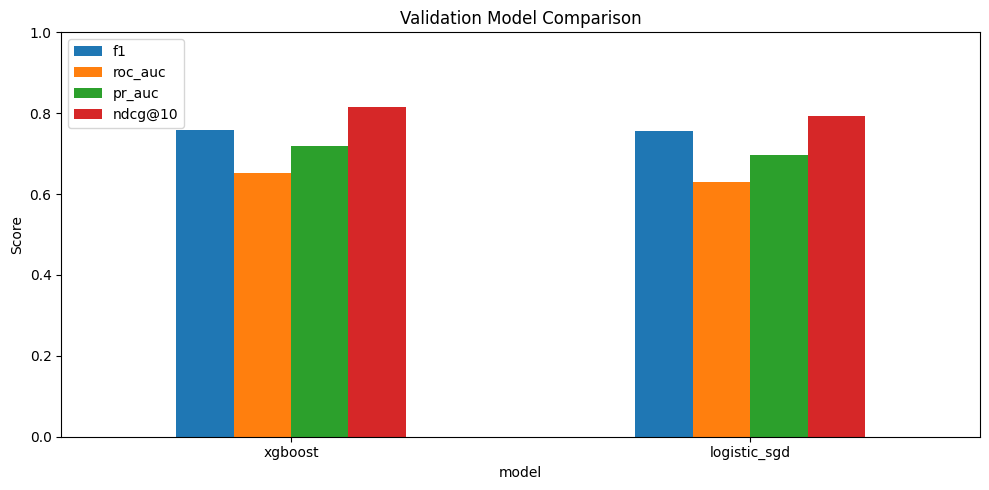

In [16]:
# ============================================================
# 12.1 VALIDATION COMPARISON PLOT
# ============================================================

plot_df = comparison_val.set_index("model")[
    ["f1", "roc_auc", "pr_auc", f"ndcg@{RANKING_K}"]
]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Validation Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Final Test Evaluation

Test set digunakan setelah pemilihan model dilakukan berdasarkan validation.

In [17]:
# ============================================================
# 13. TEST EVALUATION
# ============================================================

log_test_score = logreg.predict_proba(X_test)[:, 1].astype(np.float32)
xgb_test_score = xgb_model.predict_proba(X_test)[:, 1].astype(np.float32)

log_test_class = classification_metrics(y_test, log_test_score, log_threshold)
xgb_test_class = classification_metrics(y_test, xgb_test_score, xgb_threshold)

log_test_rank = ranking_metrics_at_k(
    users_test, y_test, log_test_score, k=RANKING_K
)
xgb_test_rank = ranking_metrics_at_k(
    users_test, y_test, xgb_test_score, k=RANKING_K
)

comparison_test = pd.DataFrame([
    {
        "model": "logistic_sgd",
        "accuracy": log_test_class["accuracy"],
        "precision": log_test_class["precision"],
        "recall": log_test_class["recall"],
        "f1": log_test_class["f1"],
        "roc_auc": log_test_class["roc_auc"],
        "pr_auc": log_test_class["pr_auc"],
        f"precision@{RANKING_K}": log_test_rank[f"precision@{RANKING_K}"],
        f"recall@{RANKING_K}": log_test_rank[f"recall@{RANKING_K}"],
        f"ndcg@{RANKING_K}": log_test_rank[f"ndcg@{RANKING_K}"],
    },
    {
        "model": "xgboost",
        "accuracy": xgb_test_class["accuracy"],
        "precision": xgb_test_class["precision"],
        "recall": xgb_test_class["recall"],
        "f1": xgb_test_class["f1"],
        "roc_auc": xgb_test_class["roc_auc"],
        "pr_auc": xgb_test_class["pr_auc"],
        f"precision@{RANKING_K}": xgb_test_rank[f"precision@{RANKING_K}"],
        f"recall@{RANKING_K}": xgb_test_rank[f"recall@{RANKING_K}"],
        f"ndcg@{RANKING_K}": xgb_test_rank[f"ndcg@{RANKING_K}"],
    },
])

display(comparison_test)

print("\nLogistic confusion matrix:")
display(pd.DataFrame(
    log_test_class["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"],
))

print("\nXGBoost confusion matrix:")
display(pd.DataFrame(
    xgb_test_class["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"],
))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,precision@10,recall@10,ndcg@10
0,logistic_sgd,0.626240,0.618889,0.985293,0.760247,0.636495,0.705713,0.797326,0.253612,0.809068
1,xgboost,0.640548,0.632516,0.960214,0.762654,0.656158,0.722451,0.811921,0.256063,0.825016



Logistic confusion matrix:


,Pred 0,Pred 1
Actual 0,132836,1440460
Actual 1,34916,2339178



XGBoost confusion matrix:


,Pred 0,Pred 1
Actual 0,248854,1324442
Actual 1,94456,2279638


## 14. Top-10 Recommendation Demo

Demo menggunakan satu user MovieLens.

Pada deployment nyata, Laravel akan mengirim hanya film yang **sedang / akan tersedia di bioskop Aoranema** sebagai candidate movies.

In [18]:
# ============================================================
# 14. TOP-10 DEMO FOR ONE USER
# ============================================================

def build_candidate_features(preference_vector, candidate_movie_positions):
    g = N_GENRES
    mg = movie_genre_matrix[candidate_movie_positions].astype(np.float32)
    pref = np.repeat(
        preference_vector.reshape(1, -1),
        repeats=len(candidate_movie_positions),
        axis=0,
    )

    X = np.empty((len(candidate_movie_positions), g * 3), dtype=np.float32)
    X[:, :g] = pref
    X[:, g:2*g] = mg
    X[:, 2*g:3*g] = pref * mg
    return X

test_user_counts = pd.Series(users_test).value_counts()
demo_user_pos = int(test_user_counts.index[0])
demo_user_id = int(user_ids[demo_user_pos])

history_idx = np.flatnonzero(
    (user_pos == demo_user_pos) & (timestamps <= VAL_END)
)
watched_movie_positions = set(movie_pos[history_idx].tolist())

all_movie_positions = np.arange(N_MOVIES, dtype=np.int32)
candidate_positions = np.array(
    [p for p in all_movie_positions if p not in watched_movie_positions],
    dtype=np.int32,
)

demo_pref = test_profile_pack["preference"][demo_user_pos]
X_candidates = build_candidate_features(demo_pref, candidate_positions)

candidate_scores = selected_model.predict_proba(X_candidates)[:, 1].astype(np.float32)

top_order = np.argsort(-candidate_scores)[:RANKING_K]
top_positions = candidate_positions[top_order]

demo_top10 = movies.iloc[top_positions][["movieId", "title", "genres"]].copy()
demo_top10["recommendation_score"] = candidate_scores[top_order]
demo_top10.insert(0, "rank", np.arange(1, len(demo_top10) + 1))

print("Demo userId:", demo_user_id)
print("Selected model:", SELECTED_MODEL_NAME)
display(demo_top10)

Demo userId: 14674
Selected model: xgboost


,rank,movieId,title,genres,recommendation_score
14939,1,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,0.876589
23005,2,116750,Deadline at Dawn (1946),Film-Noir|Mystery|Romance|Thriller,0.855188
4392,3,4496,D.O.A. (1988),Film-Noir|Mystery|Thriller,0.826699
2116,4,2206,Suspicion (1941),Film-Noir|Mystery|Thriller,0.826699
1181,5,1212,"Third Man, The (1949)",Film-Noir|Mystery|Thriller,0.826699
19740,6,102432,"Blueprint for Murder, A (1953)",Film-Noir|Mystery|Thriller,0.826699
1559,7,1617,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller,0.820649
3934,8,4037,House of Games (1987),Crime|Film-Noir|Mystery|Thriller,0.820649
9033,9,26875,"Pure Formality, A (Pura formalità, Una) (1994)",Crime|Film-Noir|Mystery|Thriller,0.820649
3558,10,3656,Lured (1947),Crime|Film-Noir|Mystery|Thriller,0.820649


## 15. Export Model & Artifacts

Output:
- Logistic baseline,
- XGBoost,
- model final terpilih,
- config feature,
- preference priors,
- validation/test metrics,
- contoh Top-10,
- ZIP artifact untuk di-download.

In [19]:
# ============================================================
# 15. EXPORT ARTIFACTS
# ============================================================

joblib.dump(
    logreg,
    ARTIFACT_DIR / "logistic_sgd.joblib",
)

xgb_model.save_model(
    ARTIFACT_DIR / "xgboost_recommender.json"
)

if SELECTED_MODEL_NAME == "xgboost":
    xgb_model.save_model(
        ARTIFACT_DIR / "final_recommender_xgboost.json"
    )
else:
    joblib.dump(
        logreg,
        ARTIFACT_DIR / "final_recommender_logistic.joblib",
    )

config = {
    "project": "Aoranema Personalized Movie Recommendation",
    "dataset": "MovieLens 32M",
    "run_mode": RUN_MODE,
    "selected_model": SELECTED_MODEL_NAME,
    "selected_threshold": float(selected_threshold),
    "rating_min": RATING_MIN,
    "rating_max": RATING_MAX,
    "neutral_rating_dropped": NEUTRAL_RATING,
    "like_threshold": LIKE_THRESHOLD,
    "preference_alpha": PREFERENCE_ALPHA,
    "profile_quantile": PROFILE_Q,
    "train_quantile": TRAIN_Q,
    "validation_quantile": VAL_Q,
    "profile_end_timestamp": PROFILE_END,
    "train_end_timestamp": TRAIN_END,
    "validation_end_timestamp": VAL_END,
    "genres": GENRES,
    "genre_slugs": GENRE_SLUGS,
    "feature_names": FEATURE_NAMES,
    "feature_layout": {
        "user_preference": [0, N_GENRES],
        "movie_genres": [N_GENRES, 2 * N_GENRES],
        "preference_x_movie_match": [2 * N_GENRES, 3 * N_GENRES],
    },
    "unknown_preference_policy": (
        "Store UNKNOWN as a separate state in the app; "
        "for model input use the smoothed global genre prior, not zero."
    ),
    "ranking_k": RANKING_K,
}

with open(ARTIFACT_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

preference_priors = {
    genre: {
        "global_mean_rating": float(mean_rating),
        "global_prior_0_1": float(prior),
    }
    for genre, mean_rating, prior in zip(
        GENRES,
        train_profile_pack["global_mean_rating"],
        train_profile_pack["global_prior"],
    )
}

with open(ARTIFACT_DIR / "preference_priors.json", "w", encoding="utf-8") as f:
    json.dump(preference_priors, f, ensure_ascii=False, indent=2)

metrics_payload = {
    "validation": comparison_val.to_dict(orient="records"),
    "test": comparison_test.to_dict(orient="records"),
    "selected_model": SELECTED_MODEL_NAME,
    "logistic_confusion_matrix_test": log_test_class["confusion_matrix"],
    "xgboost_confusion_matrix_test": xgb_test_class["confusion_matrix"],
}

with open(ARTIFACT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, ensure_ascii=False, indent=2)

comparison_val.to_csv(
    ARTIFACT_DIR / "validation_model_comparison.csv",
    index=False,
)
comparison_test.to_csv(
    ARTIFACT_DIR / "test_model_comparison.csv",
    index=False,
)
demo_top10.to_csv(
    ARTIFACT_DIR / "demo_top10.csv",
    index=False,
)

zip_path = shutil.make_archive(
    "/kaggle/working/aoranema_recommender_artifacts",
    "zip",
    ARTIFACT_DIR,
)

print("Artifacts saved to:", ARTIFACT_DIR)
print("ZIP:", zip_path)

print("\nFiles:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print("-", p.name, f"({p.stat().st_size / 1024 / 1024:.2f} MB)")

Artifacts saved to: /kaggle/working/aoranema_recommender_artifacts
ZIP: /kaggle/working/aoranema_recommender_artifacts.zip

Files:
- demo_top10.csv (0.00 MB)
- final_recommender_xgboost.json (2.27 MB)
- logistic_sgd.joblib (0.00 MB)
- metrics.json (0.00 MB)
- model_config.json (0.00 MB)
- preference_priors.json (0.00 MB)
- test_model_comparison.csv (0.00 MB)
- validation_model_comparison.csv (0.00 MB)
- xgboost_recommender.json (2.27 MB)


# 16. Integrasi Aoranema Setelah Model Stabil

```text
Laravel Backend
    │
    ├── onboarding
    ├── wishlist
    ├── booking
    └── rating
    │
    ▼
Python ML Service
    │
    ├── Preference Builder / Updater
    │       ↓
    │   user preference vector
    │
    ├── Feature Builder
    │       ↓
    │   preference + movie genres + match
    │
    ├── Final Recommender Model
    │       ↓
    │   recommendation score per film
    │
    └── Ranker
            ↓
          Top-10
            ↓
Laravel Backend
            ↓
Frontend — "Rekomendasi Untukmu"
```

### Catatan penting
`wishlist` dan `booking` **tidak menjadi feature langsung model v1**, karena MovieLens tidak mempunyai tipe interaksi tersebut.

Keduanya nanti dipakai oleh **Preference Updater** sebagai implicit feedback untuk memperbarui profil user. Rating menjadi explicit feedback yang lebih kuat.

Logic Preference Updater deployment dibuat setelah hasil training ini stabil agar skala preference aplikasi konsisten dengan skala preference saat training.